In [1]:
import joblib
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")

X_test = joblib.load("../features/X_test.pkl")
y_test = joblib.load("../features/y_test.pkl")

# Combine train + val for CV tuning
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

In [2]:
lr = joblib.load("../models/logistic_regression_model.pkl")
rf = joblib.load("../models/random_forest_model.pkl")
xgb = joblib.load("../models/xgb_optuna_model.pkl")
svm = joblib.load("../models/svm_optuna_model.pkl")

In [3]:
print(type(lr))
print(type(rf))
print(type(xgb))
print(type(svm))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.svm._classes.SVC'>


In [4]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("xgb", xgb),
        ("svm", svm)
    ],
    final_estimator=LogisticRegression(class_weight="balanced"),
    stack_method="predict_proba",
    n_jobs=-1
)

In [5]:
stack.fit(X_train_full, y_train_full);

In [6]:
val_probs = stack.predict_proba(X_val)[:,1]

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [7]:
thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t,precision,recall,f1))

results = np.array(results)

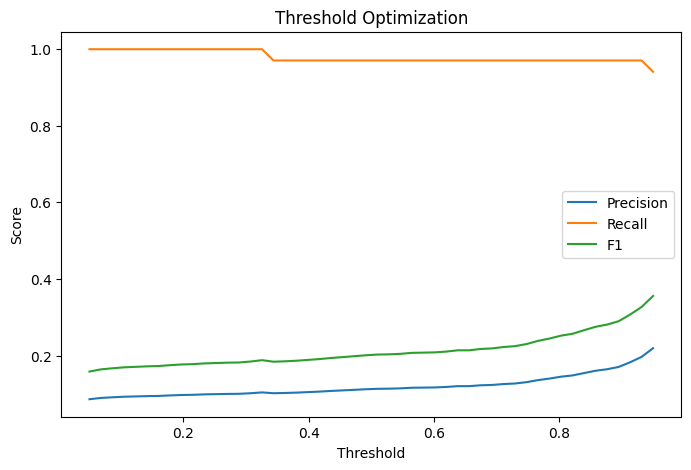

In [8]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Precision")
plt.plot(results[:,0],results[:,2],label="Recall")
plt.plot(results[:,0],results[:,3],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

In [9]:
best_index = np.argmax(results[:,3])
best_threshold = results[best_index,0]

print("Best Threshold:",best_threshold)
print("Best F1:",results[best_index,3])

Best Threshold: 0.95
Best F1: 0.35555555555555557


In [10]:
best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [11]:
print("Accuracy:", accuracy_score(y_val,val_preds))
print("Precision:", precision_score(y_val,val_preds))
print("Recall:", recall_score(y_val,val_preds))
print("F1:", f1_score(y_val,val_preds))
print("ROC-AUC:", roc_auc_score(y_val,val_probs))

Accuracy: 0.9843158464034614
Precision: 0.2191780821917808
Recall: 0.9411764705882353
F1: 0.35555555555555557
ROC-AUC: 0.997507071288173


In [12]:
print(classification_report(y_val,val_preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7362
           1       0.22      0.94      0.36        34

    accuracy                           0.98      7396
   macro avg       0.61      0.96      0.67      7396
weighted avg       1.00      0.98      0.99      7396



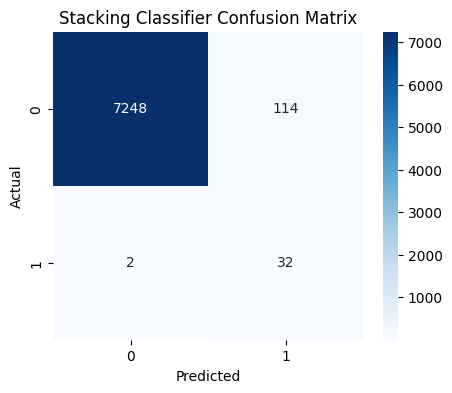

In [13]:
cm = confusion_matrix(y_val,val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Classifier Confusion Matrix")

plt.show()

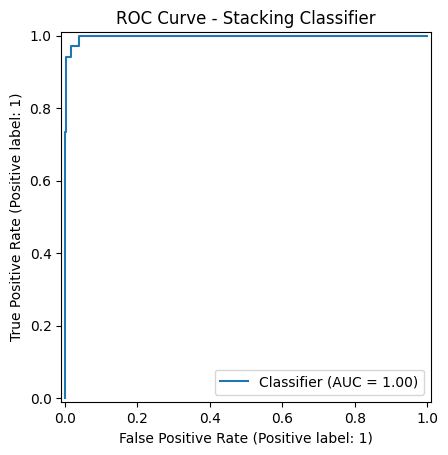

In [14]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - Stacking Classifier")

plt.show()

In [18]:
import pandas as pd
from sklearn.inspection import permutation_importance
feature_names = [
    "cyclones_total",
    "disturbances_total",
    "disturbance_ratio",
    "cyclone_5yr_avg",
    "season_monsoon",
    "season_post_monsoon",
    "season_pre_monsoon",
    "season_winter",
    "cyclones_prev_month",
    "cyclones_prev_3mo",
    "cyclones_prev_6mo"
]

perm_importance = permutation_importance(stack, X_test, y_test)
features = np.array(feature_names)
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")


c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\val

IndexError: index 12 is out of bounds for axis 0 with size 11

In [16]:
# Check the actual feature names in X_test
print("Number of features in X_test:", X_test.shape[1])
if hasattr(X_test, 'columns'):
    print("Feature names from X_test:")
    print(X_test.columns.tolist())

Number of features in X_test: 13
Feature names from X_test:
['DAY', 'cyclones_total', 'disturbances_total', 'disturbance_ratio', 'cyclone_5yr_avg', 'season_monsoon', 'season_post_monsoon', 'season_pre_monsoon', 'season_winter', 'cyclones_prev_day', 'cyclones_prev_3d', 'cyclones_prev_7d', 'year']


In [17]:
test_preds = stack.predict(X_test)
test_probs = stack.predict_proba(X_test)[:,1]

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\val

TEST ROC-AUC: 0.9932413585942026
TEST F1: 0.24836601307189543


In [19]:
joblib.dump(
    stack,
    "../models/stacking_model.pkl"
)

['../models/stacking_model.pkl']